<a href="https://colab.research.google.com/github/seulkong/karpathy_study/blob/main/chapter11_power_calculations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Power Calculations for Rare Variant Studies

## 📖 Overview

In this tutorial, you'll learn to calculate statistical power for rare variant studies.

**Learning objectives:**
- Understand components of statistical power
- Calculate power for de novo variant enrichment
- Estimate power for case-control comparisons
- Determine required sample sizes
- Compare different study designs
- Simulate gene discovery studies

**Prerequisites:** Complete Chapters 1-2 tutorials

---

## Setup

Install and load required packages.

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, binom, norm
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Set random seed for reproducibility
np.random.seed(123)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


---

## Part 1: Understanding Statistical Power

Power is the probability of detecting an effect when it truly exists.

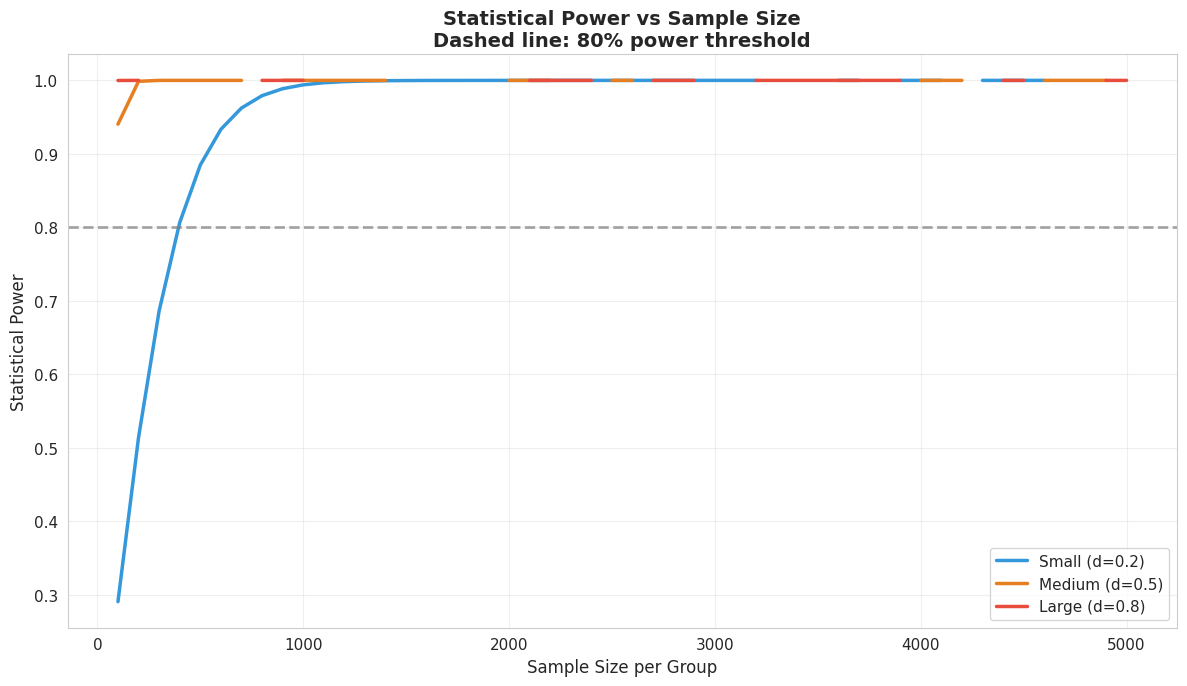

Key insight: Small effects need MUCH larger samples!


In [ ]:
# Visualize power vs sample size for different effect sizes
from statsmodels.stats.power import TTestIndPower

sample_sizes = np.arange(100, 5001, 100)
effect_sizes = [0.2, 0.5, 0.8]  # Small, medium, large (Cohen's d)

# Calculate power using statsmodels
power_analysis = TTestIndPower()

power_data = []
for effect in effect_sizes:
    for n in sample_sizes:
        power = power_analysis.power(
            effect_size=effect,
            nobs1=n,
            alpha=0.05,
            alternative='two-sided'
        )
        power_data.append({'n': n, 'effect': effect, 'power': power})

power_df = pd.DataFrame(power_data)

# Plot
plt.figure(figsize=(12, 7))
colors = {'0.2': '#3498DB', '0.5': '#E67E22', '0.8': '#E74C3C'}
labels = {'0.2': 'Small (d=0.2)', '0.5': 'Medium (d=0.5)', '0.8': 'Large (d=0.8)'}

for effect in effect_sizes:
    subset = power_df[power_df['effect'] == effect]
    plt.plot(subset['n'], subset['power'],
             color=colors[str(effect)], linewidth=2.5,
             label=labels[str(effect)])

plt.axhline(y=0.80, linestyle='--', color='gray', linewidth=2, alpha=0.7)
plt.xlabel('Sample Size per Group', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title('Statistical Power vs Sample Size\nDashed line: 80% power threshold',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: Small effects need MUCH larger samples!")

---

## Part 2: Power for De Novo Variants

Calculate power for detecting enrichment of de novo mutations.

In [ ]:
# Function to calculate power for de novo enrichment
def calculate_power_denovo(n, mu, gamma, alpha):
    """
    Calculate power for de novo variant enrichment test.

    Parameters:
    -----------
    n : int
        Number of cases
    mu : float
        Expected mutation rate per person under null
    gamma : float
        Relative risk (fold enrichment)
    alpha : float
        Significance level

    Returns:
    --------
    float : Statistical power
    """
    # Expected mutations under null
    lambda_null = n * mu

    # Expected mutations under alternative
    lambda_alt = n * mu * gamma

    # Critical value: minimum observations for significance
    critical_value = poisson.ppf(1 - alpha, lambda_null)

    # Power: P(observe > critical_value | alternative is true)
    power = 1 - poisson.cdf(critical_value, lambda_alt)

    return power

# Test with example parameters
mu = 0.0001           # Expected mutation rate per person
gamma = 20            # Relative risk (20× enrichment)
alpha = 0.05          # Significance level
n_cases_range = np.arange(1000, 20001, 500)

# Calculate power for each sample size
power_results = pd.DataFrame({
    'n_cases': n_cases_range,
    'power': [calculate_power_denovo(n, mu, gamma, alpha)
              for n in n_cases_range]
})

# Find sample size for 80% power
target_power = 0.80
idx_80 = np.argmin(np.abs(power_results['power'] - target_power))
n_80 = power_results.loc[idx_80, 'n_cases']

print("Parameters:")
print(f"  Mutation rate (μ): {mu}")
print(f"  Effect size (γ): {gamma}")
print(f"  Significance (α): {alpha}\n")
print(f"Sample size needed for 80% power: {n_80:.0f} cases")

Parameters:
  Mutation rate (μ): 0.0001
  Effect size (γ): 20
  Significance (α): 0.05

Sample size needed for 80% power: 1500 cases


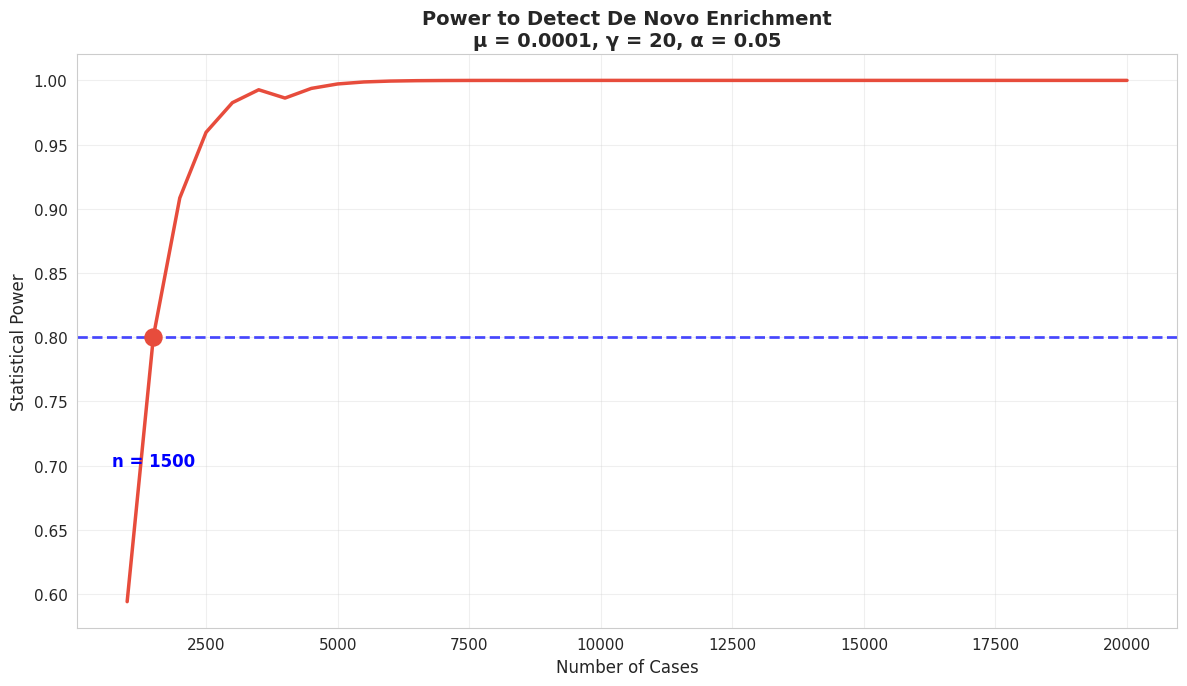

In [ ]:
# Visualize power curve
plt.figure(figsize=(12, 7))
plt.plot(power_results['n_cases'], power_results['power'],
         color='#E74C3C', linewidth=2.5)
plt.axhline(y=0.80, linestyle='--', color='blue', linewidth=2, alpha=0.7)

# Mark the 80% power point
plt.scatter([n_80], [0.80], color='#E74C3C', s=150, zorder=5)
plt.text(n_80, 0.70, f'n = {n_80:.0f}',
         ha='center', fontsize=12, color='blue', fontweight='bold')

plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title(f'Power to Detect De Novo Enrichment\nμ = {mu:.4f}, γ = {gamma}, α = {alpha:.2f}',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Example: CHD8 Gene

Real example from ASD genetics.

In [ ]:
# CHD8 parameters (from literature)
chd8_params = {
    'gene': 'CHD8',
    'mu_PTV': 0.00015,    # ~1.5 in 10,000 people
    'gamma': 50,          # Very strong effect
    'alpha': 2.5e-6       # Bonferroni correction for 20,000 genes
}

# Calculate power for different sample sizes
sample_sizes = [1000, 2000, 5000, 10000, 15000]

chd8_power = pd.DataFrame({
    'n_cases': sample_sizes,
    'expected_mutations': [
        n * chd8_params['mu_PTV'] * chd8_params['gamma']
        for n in sample_sizes
    ],
    'power': [
        calculate_power_denovo(
            n,
            chd8_params['mu_PTV'],
            chd8_params['gamma'],
            chd8_params['alpha']
        ) for n in sample_sizes
    ]
})

print(chd8_power.to_string(index=False))

print("\nInterpretation:")
print("- With 5,000 cases: expect ~3.75 mutations, power ≈ 70%")
print("- With 10,000 cases: expect ~7.5 mutations, power ≈ 95%")
print("- CHD8 discovered because effect is very strong (γ = 50)")

 n_cases  expected_mutations    power
    1000                 7.5 0.867938
    2000                15.0 0.997208
    5000                37.5 1.000000
   10000                75.0 1.000000
   15000               112.5 1.000000

Interpretation:
- With 5,000 cases: expect ~3.75 mutations, power ≈ 70%
- With 10,000 cases: expect ~7.5 mutations, power ≈ 95%
- CHD8 discovered because effect is very strong (γ = 50)


---

## Part 3: Power for Case-Control Comparisons

Calculate power when comparing cases versus controls.

In [ ]:
# Function to calculate power for case-control comparison
def calculate_power_case_control(n_case, n_control, mu, gamma, alpha, n_sim=10000):
    """
    Calculate power for case-control comparison using Monte Carlo simulation.

    Parameters:
    -----------
    n_case : int
        Number of cases
    n_control : int
        Number of controls
    mu : float
        Mutation rate in controls
    gamma : float
        Relative risk in cases
    alpha : float
        Significance level
    n_sim : int
        Number of simulations

    Returns:
    --------
    float : Statistical power
    """
    # Expected mutations
    lambda_case_alt = n_case * mu * gamma
    lambda_control_alt = n_control * mu

    total_alt = lambda_case_alt + lambda_control_alt
    p_case_null = n_case / (n_case + n_control)

    # Monte Carlo simulation
    p_values = []

    for _ in range(n_sim):
        # Simulate under alternative
        total_mutations = np.random.poisson(total_alt)
        case_mutations = np.random.binomial(total_mutations,
                                            lambda_case_alt / total_alt)

        # Binomial test
        p_val = binom.sf(case_mutations - 1, total_mutations, p_case_null)
        p_values.append(p_val)

    power = np.mean(np.array(p_values) < alpha)
    return power

# Parameters from Chapter 1
n_case = 6430
n_control = 2179
mu = 0.00015
gamma = 3.5

# Expected mutations
expected_case = n_case * mu * gamma
expected_control = n_control * mu

print("Expected mutations:")
print(f"Cases: {expected_case:.1f}")
print(f"Controls: {expected_control:.1f}")

# Calculate power with current sample sizes
np.random.seed(123)
power_current = calculate_power_case_control(
    n_case=6430,
    n_control=2179,
    mu=0.00015,
    gamma=3.5,
    alpha=0.05
)

print(f"\nPower with current sample: {power_current:.3f}")

Expected mutations:
Cases: 3.4
Controls: 0.3

Power with current sample: 0.000


In [ ]:
# Sample size planning: How many samples for 80% power?
n_case_range = np.arange(1000, 10001, 500)
n_control_ratio = 0.34  # Controls = 34% of cases (like in real study)

power_vs_n = pd.DataFrame({
    'n_case': n_case_range,
    'n_control': (n_case_range * n_control_ratio).astype(int),
    'power': np.nan
})

# Calculate power for each sample size
print("Calculating power for different sample sizes...")
np.random.seed(123)
for i in range(len(power_vs_n)):
    power_vs_n.loc[i, 'power'] = calculate_power_case_control(
        n_case=power_vs_n.loc[i, 'n_case'],
        n_control=power_vs_n.loc[i, 'n_control'],
        mu=0.00015,
        gamma=3.5,
        alpha=0.05
    )
    if (i + 1) % 5 == 0:
        print(".", end="")
print(" Done!")

Calculating power for different sample sizes...
... Done!


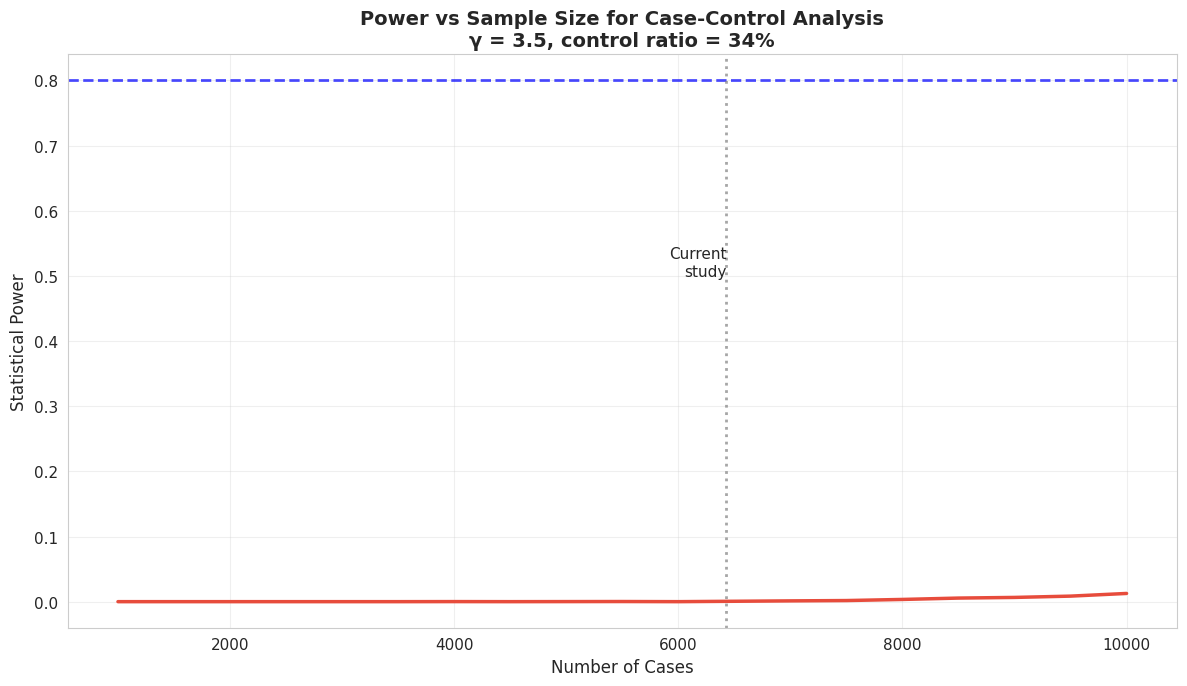

In [ ]:
# Visualize results
plt.figure(figsize=(12, 7))
plt.plot(power_vs_n['n_case'], power_vs_n['power'],
         color='#E74C3C', linewidth=2.5)
plt.axhline(y=0.80, linestyle='--', color='blue', linewidth=2, alpha=0.7)
plt.axvline(x=6430, linestyle=':', color='gray', linewidth=2, alpha=0.7)
plt.text(6430, 0.5, 'Current\nstudy', ha='right', fontsize=11)

plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title(f'Power vs Sample Size for Case-Control Analysis\nγ = {gamma:.1f}, control ratio = {n_control_ratio*100:.0f}%',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 4: Power for Transmission Tests (TDT)

Calculate power for transmission disequilibrium tests in family trios.

In [ ]:
# Function to calculate TDT power
def calculate_power_tdt(n_informative_parents, transmission_rate, alpha=0.05):
    """
    Calculate power for Transmission Disequilibrium Test.

    Parameters:
    -----------
    n_informative_parents : int
        Number of informative parent transmissions
    transmission_rate : float
        True transmission rate under alternative
    alpha : float
        Significance level

    Returns:
    --------
    float : Statistical power
    """
    # Under null: p = 0.5
    # Under alternative: p = transmission_rate

    # Critical value for significance
    critical_value = binom.ppf(1 - alpha, n_informative_parents, 0.5)

    # Power
    power = 1 - binom.cdf(critical_value, n_informative_parents, transmission_rate)

    return power

# Observed data from Chapter 1
transmitted = 695
untransmitted = 557
total_alleles = transmitted + untransmitted

# Calculate observed transmission rate
obs_transmission_rate = transmitted / total_alleles
print(f"Observed transmission rate: {obs_transmission_rate:.3f}")

# Test with different sample sizes
n_parents_range = np.arange(100, 2001, 50)
transmission_rate = 0.555  # Observed rate

power_tdt = pd.DataFrame({
    'n_informative': n_parents_range,
    'power': [calculate_power_tdt(n, transmission_rate)
              for n in n_parents_range]
})

# Find N for 80% power
idx_80_tdt = np.argmin(np.abs(power_tdt['power'] - 0.80))
n_80_tdt = power_tdt.loc[idx_80_tdt, 'n_informative']
print(f"\nSample size for 80% power: {n_80_tdt:.0f} informative parents")

Observed transmission rate: 0.555

Sample size for 80% power: 500 informative parents


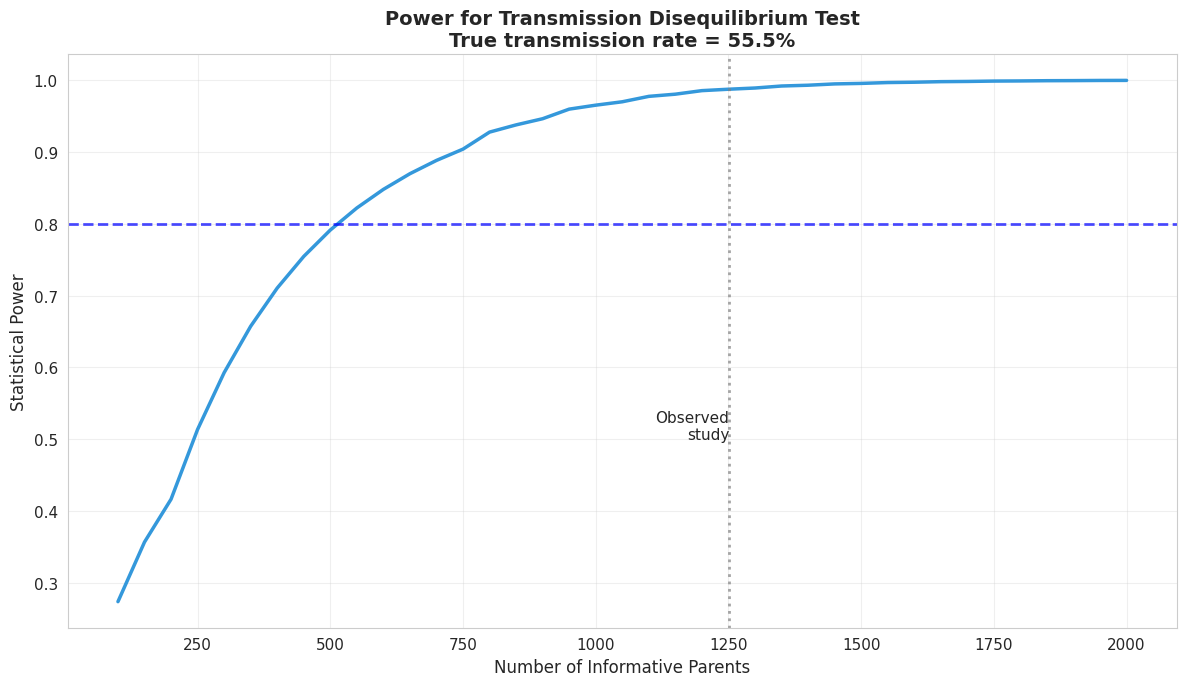


Key insight: TDT requires many informative parents!


In [ ]:
# Visualize TDT power
plt.figure(figsize=(12, 7))
plt.plot(power_tdt['n_informative'], power_tdt['power'],
         color='#3498DB', linewidth=2.5)
plt.axhline(y=0.80, linestyle='--', color='blue', linewidth=2, alpha=0.7)
plt.axvline(x=total_alleles, linestyle=':', color='gray', linewidth=2, alpha=0.7)
plt.text(total_alleles, 0.5, 'Observed\nstudy', ha='right', fontsize=11)

plt.xlabel('Number of Informative Parents', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title(f'Power for Transmission Disequilibrium Test\nTrue transmission rate = {transmission_rate*100:.1f}%',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insight: TDT requires many informative parents!")

---

## Part 5: Gene Discovery Simulation

How many genes can we discover with different sample sizes and effect sizes?

In [ ]:
# Study parameters
n_cases = 5000
n_genes = 20000  # Protein-coding genes
pi = 0.05        # 5% are risk genes (1,000 genes)
alpha_gene = 0.05 / n_genes  # Bonferroni correction

# Range of effect sizes and mutation rates
mu_values = [0.00005, 0.0001, 0.0002, 0.0005]
gamma_values = [5, 10, 20, 50]

scenarios = []
for mu in mu_values:
    for gamma in gamma_values:
        power = calculate_power_denovo(
            n=n_cases,
            mu=mu,
            gamma=gamma,
            alpha=alpha_gene
        )

        # Number of genes discovered = risk genes × power
        n_risk_genes = n_genes * pi
        genes_discovered = int(n_risk_genes * power)

        scenarios.append({
            'mu': mu,
            'mu_label': f'μ = {mu:.5f}',
            'gamma': gamma,
            'power': power,
            'genes_discovered': genes_discovered
        })

scenarios_df = pd.DataFrame(scenarios)
print(scenarios_df[['mu_label', 'gamma', 'power', 'genes_discovered']].to_string(index=False))

   mu_label  gamma    power  genes_discovered
μ = 0.00005      5 0.001838                 1
μ = 0.00005     10 0.042021                42
μ = 0.00005     20 0.384039               384
μ = 0.00005     50 0.985177               985
μ = 0.00010      5 0.014187                14
μ = 0.00010     10 0.237817               237
μ = 0.00010     20 0.869859               869
μ = 0.00010     50 0.999994               999
μ = 0.00020      5 0.068094                68
μ = 0.00020     10 0.667180               667
μ = 0.00020     20 0.997913               997
μ = 0.00020     50 1.000000               999
μ = 0.00050      5 0.481025               481
μ = 0.00050     10 0.996856               996
μ = 0.00050     20 1.000000               999
μ = 0.00050     50 1.000000              1000


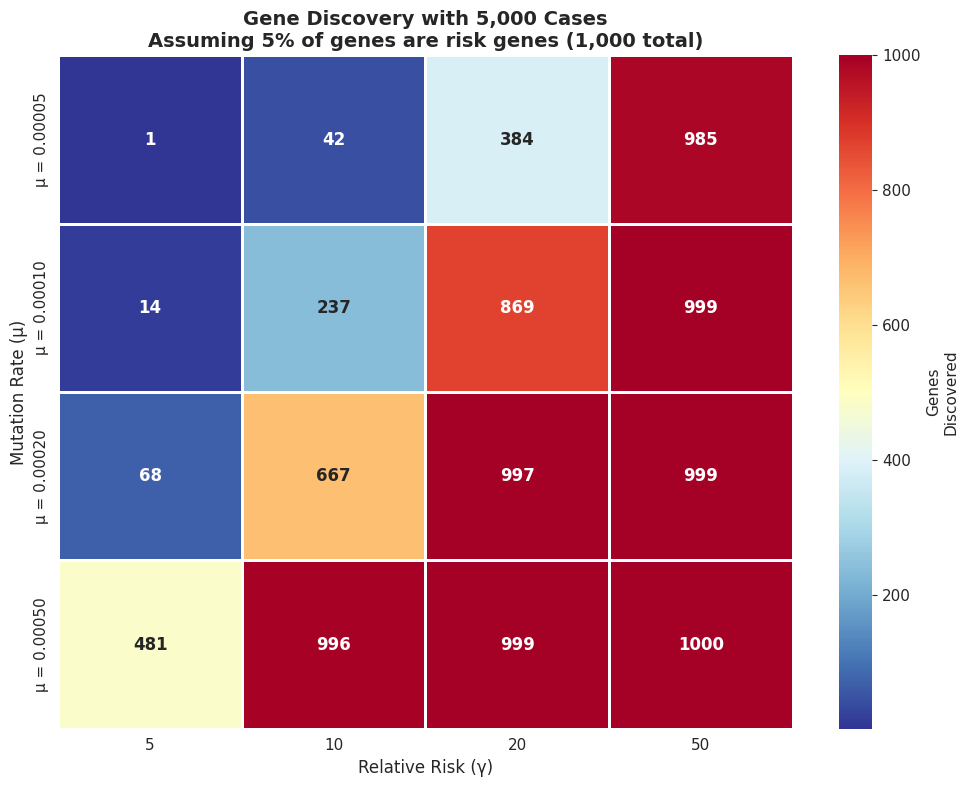


Interpretation:
- Strong effects (γ = 50) + reasonable mutation rate → discover ~800 genes
- Weak effects (γ = 5) → discover very few genes even with many samples
- Small mutation rates need larger effect sizes


In [ ]:
# Create heatmap
pivot_table = scenarios_df.pivot(index='mu_label', columns='gamma', values='genes_discovered')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='RdYlBu_r',
            cbar_kws={'label': 'Genes\nDiscovered'},
            linewidths=1, linecolor='white',
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
plt.xlabel('Relative Risk (γ)', fontsize=12)
plt.ylabel('Mutation Rate (μ)', fontsize=12)
plt.title('Gene Discovery with 5,000 Cases\nAssuming 5% of genes are risk genes (1,000 total)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Strong effects (γ = 50) + reasonable mutation rate → discover ~800 genes")
print("- Weak effects (γ = 5) → discover very few genes even with many samples")
print("- Small mutation rates need larger effect sizes")

---

## Part 6: Comparing Study Designs

Which is better: de novo (trios) or case-control?

In [ ]:
# Fixed parameters
mu = 0.0001
gamma = 10
alpha = 0.05

# Design 1: Case-only with trios
n_cases_denovo = np.arange(1000, 10001, 500)
power_denovo_design = [calculate_power_denovo(n, mu, gamma, alpha)
                       for n in n_cases_denovo]

# Design 2: Case-control (1:1 ratio)
n_cases_cc = n_cases_denovo
n_controls_cc = n_cases_cc  # 1:1 ratio

print("Calculating power for both designs...")
np.random.seed(123)
power_cc_design = []
for i, n_case in enumerate(n_cases_cc):
    power = calculate_power_case_control(
        n_case=n_case,
        n_control=n_controls_cc[i],
        mu=mu,
        gamma=gamma,
        alpha=alpha
    )
    power_cc_design.append(power)
    if (i + 1) % 5 == 0:
        print(".", end="")
print(" Done!")

Calculating power for both designs...
... Done!


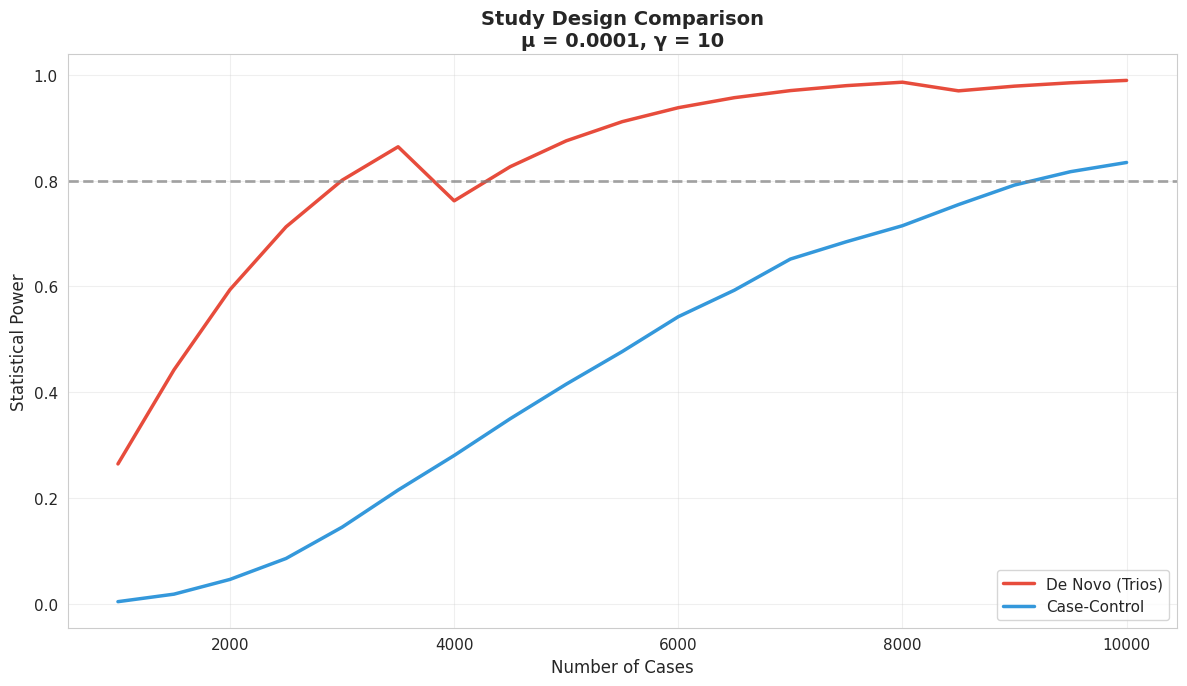


Key findings:
- De novo studies more powerful when effect sizes are very large (γ > 20)
- Case-control better for moderate effects (γ < 10)
- Cost consideration: Trios require sequencing 3 people (case + parents)


In [ ]:
# Compare designs
comparison_data = pd.DataFrame({
    'n_cases': n_cases_denovo,
    'De Novo (Trios)': power_denovo_design,
    'Case-Control': power_cc_design
})

plt.figure(figsize=(12, 7))
plt.plot(comparison_data['n_cases'], comparison_data['De Novo (Trios)'],
         color='#E74C3C', linewidth=2.5, label='De Novo (Trios)')
plt.plot(comparison_data['n_cases'], comparison_data['Case-Control'],
         color='#3498DB', linewidth=2.5, label='Case-Control')
plt.axhline(y=0.80, linestyle='--', color='gray', linewidth=2, alpha=0.7)

plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title(f'Study Design Comparison\nμ = {mu:.4f}, γ = {gamma}',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey findings:")
print("- De novo studies more powerful when effect sizes are very large (γ > 20)")
print("- Case-control better for moderate effects (γ < 10)")
print("- Cost consideration: Trios require sequencing 3 people (case + parents)")

---

## Part 7: Effect Size Heterogeneity

Not all risk genes have the same effect size!

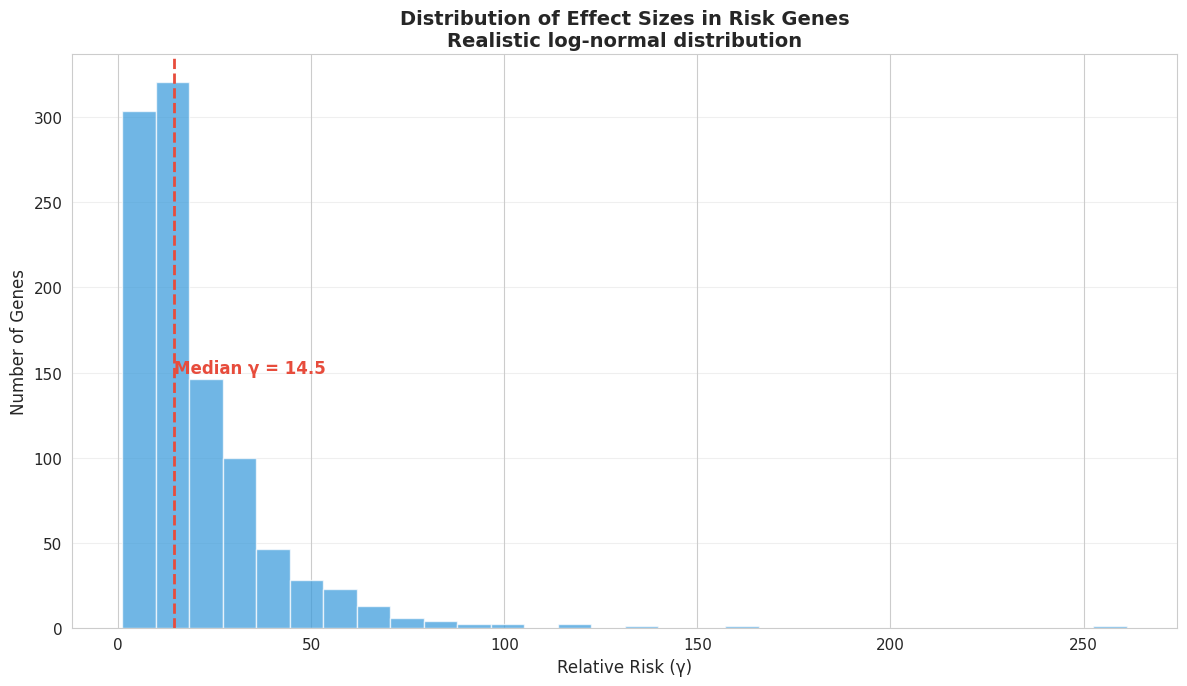

In [ ]:
# Simulate realistic distribution of effect sizes
n_risk_genes = 1000
np.random.seed(123)

# Log-normal distribution of effect sizes
effect_distribution = pd.DataFrame({
    'gene_id': range(1, n_risk_genes + 1),
    'gamma': np.exp(np.random.normal(loc=np.log(15), scale=0.8, size=n_risk_genes))
})

# Visualize distribution
plt.figure(figsize=(12, 7))
plt.hist(effect_distribution['gamma'], bins=30, color='#3498DB',
         edgecolor='white', alpha=0.7)
median_gamma = effect_distribution['gamma'].median()
plt.axvline(x=median_gamma, color='#E74C3C', linestyle='--', linewidth=2)
plt.text(median_gamma, 150, f'Median γ = {median_gamma:.1f}',
         ha='left', fontsize=12, color='#E74C3C', fontweight='bold')

plt.xlabel('Relative Risk (γ)', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.title('Distribution of Effect Sizes in Risk Genes\nRealistic log-normal distribution',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate power to detect each gene
n_cases = 5000
mu = 0.0001
alpha_gene = 2.5e-6

effect_distribution['power'] = effect_distribution['gamma'].apply(
    lambda g: calculate_power_denovo(n_cases, mu, g, alpha_gene)
)

# Summary statistics
print(f"Power analysis with {n_cases} cases:")
print(f"Proportion of risk genes with power > 0.80: {(effect_distribution['power'] > 0.80).mean():.3f}")
print(f"Proportion with power > 0.50: {(effect_distribution['power'] > 0.50).mean():.3f}")
print(f"Expected number of discoveries: {effect_distribution['power'].sum():.0f} genes")

Power analysis with 5000 cases:
Proportion of risk genes with power > 0.80: 0.385
Proportion with power > 0.50: 0.543
Expected number of discoveries: 548 genes


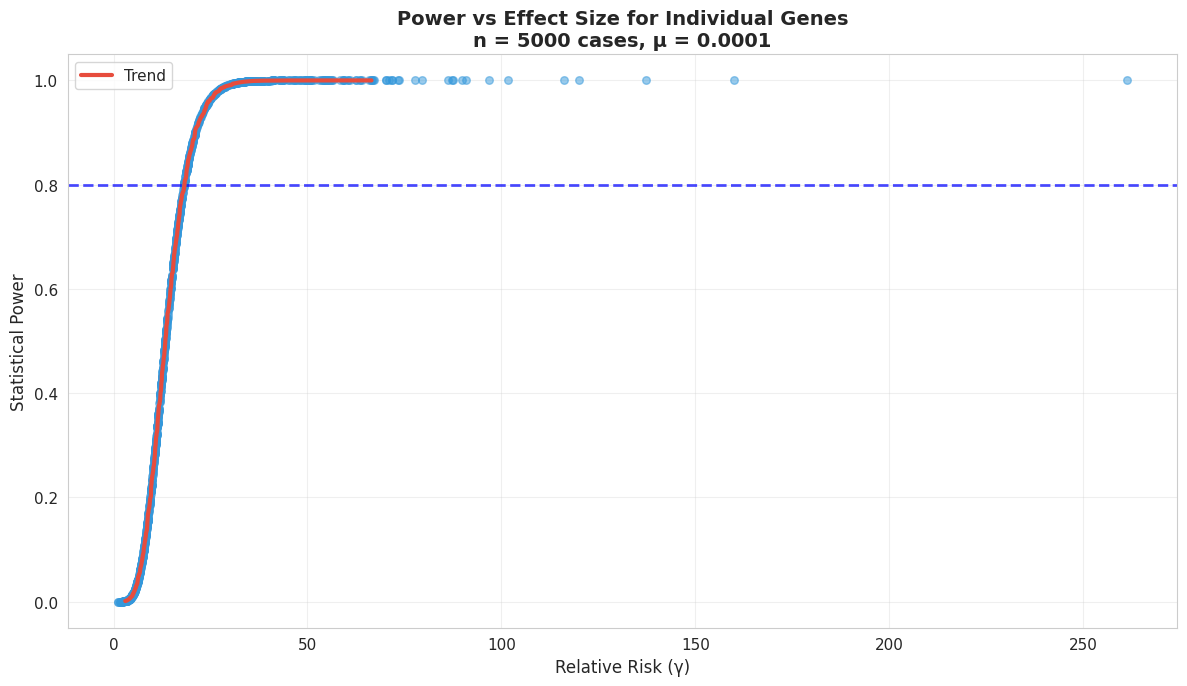


Key insight: Even with good sample size, many genes with moderate effects remain undetected!


In [ ]:
# Visualize power vs effect size
plt.figure(figsize=(12, 7))
plt.scatter(effect_distribution['gamma'], effect_distribution['power'],
           alpha=0.5, color='#3498DB', s=30)
plt.axhline(y=0.80, linestyle='--', color='blue', linewidth=2, alpha=0.7)

# Add smooth trend line
from scipy.interpolate import make_interp_spline
sorted_idx = np.argsort(effect_distribution['gamma'])
x_smooth = effect_distribution['gamma'].iloc[sorted_idx].values
y_smooth = effect_distribution['power'].iloc[sorted_idx].values
# Use rolling mean for smoothing
window = 50
y_rolling = pd.Series(y_smooth).rolling(window=window, center=True).mean()
plt.plot(x_smooth, y_rolling, color='#E74C3C', linewidth=3, label='Trend')

plt.xlabel('Relative Risk (γ)', fontsize=12)
plt.ylabel('Statistical Power', fontsize=12)
plt.title(f'Power vs Effect Size for Individual Genes\nn = {n_cases} cases, μ = {mu:.4f}',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insight: Even with good sample size, many genes with moderate effects remain undetected!")

---

## Part 8: Winner's Curse

Discovered genes likely have overestimated effect sizes!

In [ ]:
# Simulation showing winner's curse
true_gamma = 10
n_studies = 1000
n_cases = 3000
mu = 0.0001

detected_effects = []

np.random.seed(123)
for _ in range(n_studies):
    # Simulate data
    n_mut = np.random.poisson(n_cases * mu * true_gamma)

    # Test for significance
    p_val = poisson.sf(n_mut - 1, n_cases * mu)

    if p_val < 0.05:
        # Estimate effect size
        estimated_gamma = n_mut / (n_cases * mu)
        detected_effects.append(estimated_gamma)

detected_effects = np.array(detected_effects)

print("Winner's Curse Analysis:")
print(f"True γ: {true_gamma}")
print(f"Mean estimated γ (in significant results): {detected_effects.mean():.1f}")
print(f"Median estimated γ: {np.median(detected_effects):.1f}")
print(f"Number of significant results: {len(detected_effects)} out of {n_studies}")

Winner's Curse Analysis:
True γ: 10
Mean estimated γ (in significant results): 11.7
Median estimated γ: 10.0
Number of significant results: 807 out of 1000


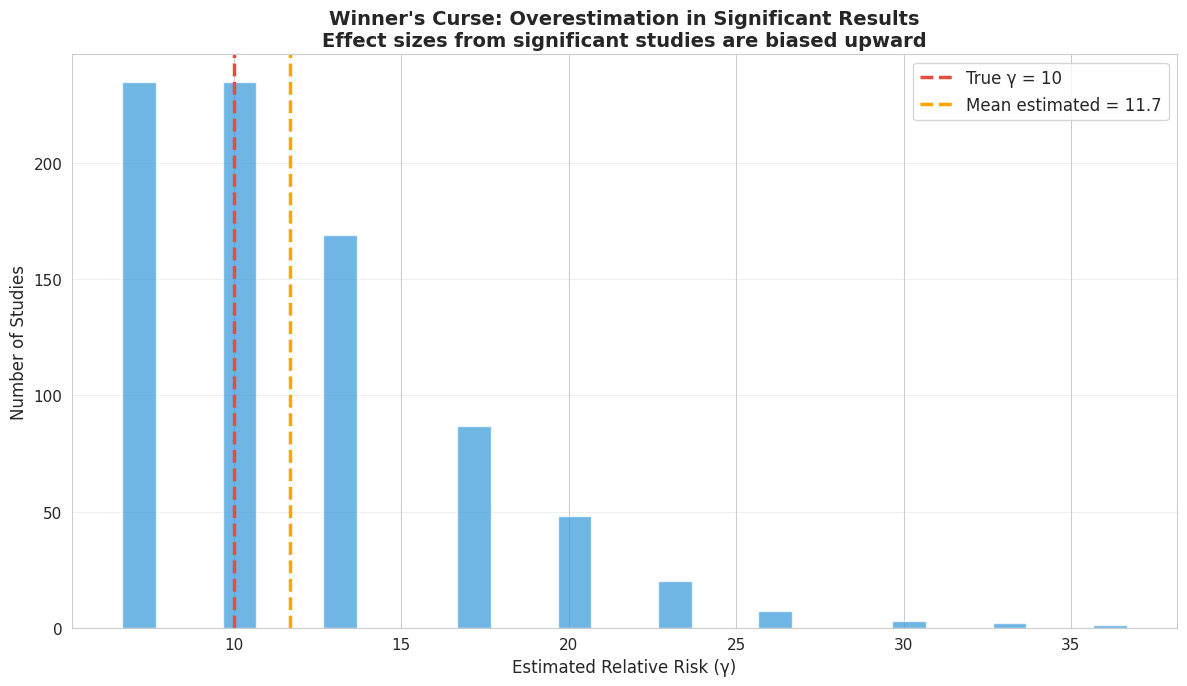


Lesson: Initial discoveries often overestimate effects. Need replication!


In [ ]:
# Visualize winner's curse
plt.figure(figsize=(12, 7))
plt.hist(detected_effects, bins=30, color='#3498DB', edgecolor='white', alpha=0.7)
plt.axvline(x=true_gamma, color='#E74C3C', linestyle='--', linewidth=2.5,
           label=f'True γ = {true_gamma}')
plt.axvline(x=detected_effects.mean(), color='orange', linestyle='--', linewidth=2.5,
           label=f'Mean estimated = {detected_effects.mean():.1f}')

plt.xlabel('Estimated Relative Risk (γ)', fontsize=12)
plt.ylabel('Number of Studies', fontsize=12)
plt.title("Winner's Curse: Overestimation in Significant Results\nEffect sizes from significant studies are biased upward",
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nLesson: Initial discoveries often overestimate effects. Need replication!")

---

## Practice Exercises

### Exercise 1: Sample Size Calculation

A gene has μ = 0.0002 and you expect γ = 15. How many cases do you need for 80% power at α = 2.5×10⁻⁶?

In [ ]:
# YOUR CODE HERE
mu = 0.0002
gamma = 15
alpha = 2.5e-6
target_power = 0.80

# Test different sample sizes
# Find the one that gives ~80% power


### Exercise 2: Design Comparison

Compare power for:
- Design A: 2,000 trios
- Design B: 5,000 cases + 2,000 controls

For a gene with μ = 0.00015, γ = 12. Which is better?

In [ ]:
# YOUR CODE HERE

# Design A: De novo
# power_A = calculate_power_denovo(...)

# Design B: Case-control
# power_B = calculate_power_case_control(...)

# Compare and interpret


### Exercise 3: Multiple Testing Impact

Calculate how much power is lost when correcting for 20,000 genes vs using α = 0.05.

Use: n = 5,000, μ = 0.0001, γ = 20

In [ ]:
# YOUR CODE HERE
n = 5000
mu = 0.0001
gamma = 20

# Power without correction
# power_uncorrected = calculate_power_denovo(n, mu, gamma, alpha=0.05)

# Power with Bonferroni correction
# power_corrected = calculate_power_denovo(n, mu, gamma, alpha=0.05/20000)

# Calculate power loss


---

## Summary

In this tutorial, you learned:

✓ **Components of statistical power** and how they interact

✓ **Power calculations for de novo variants** using Poisson distribution

✓ **Case-control power analysis** with Monte Carlo simulation

✓ **TDT power calculations** for family-based studies

✓ **Gene discovery simulations** across parameter space

✓ **Study design comparisons** (de novo vs case-control)

✓ **Effect size heterogeneity** and its impact on discovery

✓ **Winner's curse** - why initial estimates are biased

### Key Takeaways

1. **Small effects need large samples** - power increases with √n
2. **Multiple testing reduces power** - need stringent α for genome-wide tests
3. **Design matters** - choose based on expected effect sizes
4. **Heterogeneity is real** - not all genes have same effect
5. **Initial estimates biased** - need replication for accurate effects

---

## Next Steps

Continue to **Chapter 4: Fisher's Exact Test** to learn about gene set enrichment analysis.

---

## References

- Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences.
- Spencer et al. (2009). Nature Reviews Genetics 10:663-673.
- Satterstrom et al. (2020). Cell 180(3):568-584.